# HBN Downstream Evaluation

Sanity-train a minimal 1D-CNN on each preprocessed HBN downstream dataset in `/scratch/agjma/HBN_SPEED_downstream_merged/` and report per-split metrics. Mirrors `downstream_evaluation.ipynb`, but splits **subject-wise** (HBN has multiple runs per subject, so `random_split` would leak subject-specific features into the validation set).

Start with `ccd_rt` (reaction-time regression). Add more datasets as their merges complete.

In [14]:
import sys, os, tempfile, warnings
sys.path.insert(0, '..')
os.environ["SLURM_JOB_NAME"] = "bash"
warnings.filterwarnings("ignore", "Can't initialize NVML")
warnings.filterwarnings("ignore", category=FutureWarning)

import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from torch.utils.data import DataLoader, Subset
from speed.dataloader import DownstreamDataset, subject_wise_split, SUBJECT_EXTRACTORS

torch.set_float32_matmul_precision("medium")
pl.seed_everything(42, workers=True)

MERGED = "/scratch/agjma/HBN_SPEED_downstream_merged"
MAX_EPOCHS = 50
MAX_SAMPLES = None    # cap train samples; None = use all
VAL_CAP = 2000         # cap val samples for fast diagnostic

[rank: 0] Seed set to 42


In [15]:
def z_normalize(x):
    """Per-channel zero-mean unit-variance normalization."""
    return (x - x.mean(dim=-1, keepdim=True)) / (x.std(dim=-1, keepdim=True) + 1e-8)


class SimpleEEG(pl.LightningModule):
    """EEGNet-lite 1D-CNN: temporal conv → depthwise spatial → separable → flatten head.

    Preserves time information through two avgpool(4) stages rather than collapsing
    with AdaptiveAvgPool1d(1). For 400-sample inputs, produces 64×25 = 1600 features.
    """

    def __init__(self, n_channels, n_outputs, task="classification", n_samples=400):
        super().__init__()
        self.save_hyperparameters()
        self.task = task
        self.net = nn.Sequential(
            # Temporal conv (kernel 25 = 125 ms @ 200 Hz, covers alpha period)
            nn.Conv1d(n_channels, 16, 25, padding=12), nn.BatchNorm1d(16), nn.ELU(),
            # Pointwise mix across feature maps
            nn.Conv1d(16, 32, 1), nn.BatchNorm1d(32), nn.ELU(),
            nn.AvgPool1d(4),  # 400 -> 100
            # Depthwise temporal + pointwise
            nn.Conv1d(32, 32, 15, padding=7, groups=32),
            nn.Conv1d(32, 64, 1), nn.BatchNorm1d(64), nn.ELU(),
            nn.AvgPool1d(4),  # 100 -> 25
            nn.Dropout(0.25),
            nn.Flatten(),
        )
        out_t = n_samples // 16  # two avgpool(4) stages
        self.head = nn.Linear(64 * out_t, n_outputs)
        self.loss_fn = nn.CrossEntropyLoss() if task == "classification" else nn.MSELoss()

    def forward(self, x):
        return self.head(self.net(x))

    def _step(self, batch, prefix):
        x, y = batch
        logits = self(x)
        # Single-target regression: head emits (B, 1); labels are (B,) → squeeze to avoid MSE broadcasting (B,B).
        if self.task == "regression" and logits.shape[-1] == 1 and y.dim() == 1:
            logits = logits.squeeze(-1)
        loss = self.loss_fn(logits, y)
        self.log(f"{prefix}_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
        if self.task == "classification":
            acc = (logits.argmax(1) == y).float().mean()
            self.log(f"{prefix}_acc", acc, on_epoch=True, on_step=False, prog_bar=True)
        return loss

    def training_step(self, batch, _):
        return self._step(batch, "train")

    def validation_step(self, batch, _):
        self._step(batch, "val")

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=1e-3)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "monitor": "val_loss"}}

In [16]:
def _read_all_labels(ds):
    """Read labels for a whole DownstreamDataset quickly, bypassing __getitem__."""
    labels = np.empty(len(ds), dtype=np.float32)
    cache = {}
    for i, (fi, li) in enumerate(ds.index):
        if fi not in cache:
            with h5py.File(ds.paths[fi], "r") as f:
                cache[fi] = f["labels"][:]
        labels[i] = cache[fi][li]
    return labels


def evaluate_hbn(name, path, n_classes=None, n_targets=None, batch_size=64):
    """Load HBN dataset, subject-wise split, train with best-weight restore, report."""
    task = "regression" if n_targets else "classification"
    ds = DownstreamDataset(path, transform=z_normalize)
    x, y = ds[0]
    n_ch, n_t = x.shape
    full_size = len(ds)

    print(f"  Total samples: {full_size:,} | Shape: ({n_ch}, {n_t})")
    if task == "classification":
        counts = ds.get_label_counts()
        desc = ds.label_descriptions or [str(k) for k in sorted(counts.keys())]
        for i, d in enumerate(desc):
            print(f"    {d}: {counts.get(i, 0):,}")
    else:
        print(f"    Targets: {y.shape[-1] if y.dim() > 0 else 1} (regression)")

    # Subject-wise split (HBN has multiple runs per subject → random split leaks).
    train_ds, val_ds, _ = subject_wise_split(
        ds, train_ratio=0.8, val_ratio=0.2, test_ratio=0.0,
        subject_extractor=SUBJECT_EXTRACTORS['hbn'],
    )

    # Optional train cap; val always capped for fast diagnostic.
    if MAX_SAMPLES is not None and len(train_ds) > MAX_SAMPLES:
        idx = torch.randperm(len(train_ds))[:MAX_SAMPLES].tolist()
        train_ds = Subset(train_ds, idx)
    if len(val_ds) > VAL_CAP:
        idx = torch.randperm(len(val_ds))[:VAL_CAP].tolist()
        val_ds = Subset(val_ds, idx)
    print(f"  Subject-wise split (post-cap): train={len(train_ds):,}, val={len(val_ds):,}")

    # Baseline R²: predict the train-label mean for every val sample (honest floor).
    if task == "regression":
        all_labels = _read_all_labels(ds)
        train_idx = train_ds.indices if isinstance(train_ds, Subset) else list(range(len(train_ds)))
        val_idx   = val_ds.indices   if isinstance(val_ds,   Subset) else list(range(len(val_ds)))
        # Unwrap nested Subset (we may have double-wrapped)
        def _flatten(sub, ds_idx):
            if isinstance(sub, Subset) and isinstance(sub.dataset, Subset):
                parent = sub.dataset
                return [parent.indices[i] for i in sub.indices]
            return ds_idx
        train_idx = _flatten(train_ds, train_idx)
        val_idx   = _flatten(val_ds,   val_idx)
        train_y = all_labels[train_idx]
        val_y   = all_labels[val_idx]
        base_mse = float(np.mean((val_y - train_y.mean()) ** 2))
        base_r2  = 1.0 - base_mse / float(np.var(val_y))
        print(f"  Baseline (predict train mean): val_mse={base_mse:.4f}  R\u00b2={base_r2:+.4f}")

    pin = torch.cuda.is_available()
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, num_workers=4,
        pin_memory=pin, persistent_workers=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, num_workers=4,
        pin_memory=pin, persistent_workers=True,
    )

    n_out = n_targets if n_targets else n_classes
    model = SimpleEEG(n_ch, n_out, task, n_samples=n_t)

    ckpt_dir = tempfile.mkdtemp(prefix=f"hbn_{name}_")
    ckpt_cb = ModelCheckpoint(
        dirpath=ckpt_dir, monitor="val_loss", mode="min",
        save_top_k=1, filename="best",
    )
    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS, accelerator="auto", devices=1,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=15, mode="min", verbose=False),
            ckpt_cb,
        ],
        enable_model_summary=False, enable_progress_bar=True, logger=False,
    )
    trainer.fit(model, train_loader, val_loader)

    # Restore best weights before reporting / predicting.
    best_path = ckpt_cb.best_model_path
    if best_path:
        device = model.device
        model = SimpleEEG.load_from_checkpoint(best_path).to(device)
        print(f"  Loaded best checkpoint: {os.path.basename(best_path)}  (val_loss={ckpt_cb.best_model_score:.4f})")

    m = trainer.callback_metrics
    stopped = trainer.current_epoch + 1
    if task == "classification":
        print(f"\n  {name}: val_acc={m.get('val_acc', 0):.3f}  val_loss={m.get('val_loss', 0):.3f}"
              f"  train_acc={m.get('train_acc', 0):.3f}  train_loss={m.get('train_loss', 0):.3f}"
              f"  (epoch {stopped})")
        print()
        return None

    print(f"\n  {name}: val_mse={m.get('val_loss', 0):.4f}  train_mse={m.get('train_loss', 0):.4f}"
          f"  (epoch {stopped})")
    print()

    # Collect validation-set predictions with the restored best weights.
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            out = model(xb.to(model.device))
            if out.shape[-1] == 1:
                out = out.squeeze(-1)
            yt.append(yb.numpy())
            yp.append(out.cpu().numpy())
    return np.concatenate(yt), np.concatenate(yp)


def plot_regression(y_true, y_pred, name):
    """Predicted-vs-observed scatter with identity line and R\u00b2."""
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.scatter(y_true, y_pred, s=10, alpha=0.25, edgecolor="none")
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.5)
    ax.set(xlim=(lo, hi), ylim=(lo, hi), aspect="equal",
           xlabel="Observed RT (s)", ylabel="Predicted RT (s)",
           title=f"{name}   R\u00b2 = {r2:.3f}")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

## HBN CCD-RT (Reaction-Time Regression)

Contrast-change detection task, target = reaction time in seconds. 105 channels, 2 s windows @ 200 Hz.

In [17]:
y_true, y_pred = evaluate_hbn("HBN-CCD-RT", f"{MERGED}/ccd_rt", n_targets=1)

  Total samples: 130,584 | Shape: (105, 400)
    Targets: 1 (regression)


/scratch/agjma/conda/EEGModel/lib/python3.12/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.12 /scratch/agjma/conda/EEGModel/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


  Subject-wise split (post-cap): train=104,201, val=2,000
  Baseline (predict train mean): val_mse=0.1333  R²=-0.0004


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [6]


Sanity Checking: |                                                                                      | 0/? …

...

Validation: |                                                                                           | 0/? …

Validation: |                                                                                           | 0/? …

Validation: |                                                                                           | 0/? …

Validation: |                                                                                           | 0/? …

  Loaded best checkpoint: best.ckpt  (val_loss=0.1123)

  HBN-CCD-RT: val_mse=0.1152  train_mse=0.1078  (epoch 26)



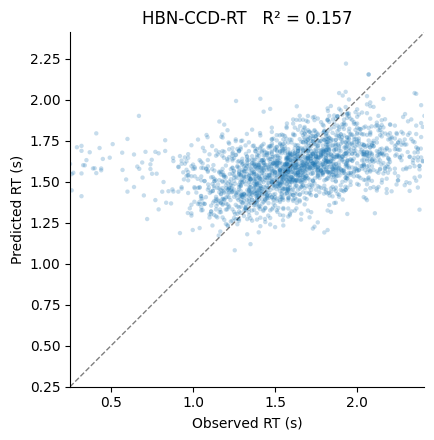

In [20]:
plot_regression(y_true, y_pred, "HBN-CCD-RT")

## Follow-up: widen the window to 4 s?

Current config (`configs/downstream/hbn_ccd_rt.yaml`): `event_tmin=0.5`, `event_tlen=2.0` — window is **[stim+0.5, stim+2.5]** locked to stimulus onset. This matches the `eeg2025/startkit/challenge_1.py` `WINDOW_LEN=2.0` benchmark convention. It covers the response for ~95 % of trials (RT p95 = 2.17 s) but only the tail of motor preparation.

Widening to `event_tmin=-0.5`, `event_tlen=4.0` → window **[stim-0.5, stim+3.5]** would add pre-stim baseline and guarantee full response coverage for every trial, which may improve RT prediction. The annotation parser at `speed/annotations.py:1140-1168` and the windowing at `speed/utils.py:185-221` both accept any `tmin`/`tlen` within recording bounds — no code change needed.

Cost: the HDF5 windows are baked in at preprocessing time, so this requires re-running `scripts/preprocess_downstream.py` with the modified config and re-merging (~6 h compute on the existing 6-shard SLURM layout). Revisit after the model/training fixes here are validated.

## Add more HBN datasets as their merges complete

```python
evaluate_hbn("HBN-CCD-CORRECT", f"{MERGED}/ccd_correct", n_classes=2)
evaluate_hbn("HBN-CBCL",        f"{MERGED}/cbcl",        n_targets=...)  # see configs/downstream/hbn_cbcl.yaml
evaluate_hbn("HBN-REST-EC-EO",  f"{MERGED}/rest_ec_eo",  n_classes=2)
evaluate_hbn("HBN-SURROUNDSUPP",f"{MERGED}/surroundsupp",n_classes=...)
evaluate_hbn("HBN-SYMBOLSEARCH",f"{MERGED}/symbolsearch",n_classes=...)
```